# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Датасет:** `synthetic_healthcare_data.csv` — синтетические данные о госпитализациях пациентов.

---
## 1. Постановка задачи

### 1.1. Что это за данные
Датасет содержит 500 записей о госпитализациях пациентов. Каждая запись включает демографические сведения (возраст, пол), клинические показатели (индекс массы тела, артериальное давление, уровень холестерина), факторы риска (курение, диабет), диагноз, стоимость лечения, даты поступления и выписки, а также исход лечения. Данные носят синтетический характер и предназначены для учебного анализа. Признаки смешанных типов: числовые, категориальные, бинарные и временные.

### 1.2. Условный заказчик
Аналитический отдел сети клиник (или страховая компания), заинтересованный в оценке качества медицинской помощи, оптимизации затрат и выявлении факторов, влияющих на исход лечения.

### 1.3. Возможные задачи интеллектуального анализа данных
1. **Описательная аналитика** — профилирование групп пациентов по диагнозам, возрасту и факторам риска; поиск закономерностей между показателями и исходом.
2. **Поиск аномалий** — выявление подозрительно высоких/низких стоимостей лечения, аномальных значений артериального давления и ИМТ.
3. **(Дополнительно) Сегментация пациентов** — кластеризация по клиническому профилю для персонализации лечения.
4. **(Дополнительно) Прогнозирование исхода лечения** — классификация (`Recovered` / `Referred` / `Deceased`).

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
print("Библиотеки успешно загружены.")

Библиотеки успешно загружены.


---
## 2. Паспорт датасета

**Смысл признаков (гипотеза по названию):**

| Признак | Смысл |
|---|---|
| `Patient_ID` | Уникальный идентификатор |
| `Age` | Возраст, лет |
| `Gender` | Пол |
| `BMI` | Индекс массы тела |
| `Blood_Pressure` | АД «сист / диаст» (строка) |
| `Cholesterol_Level` | Холестерин |
| `Smoker` / `Diabetic` | Факторы риска (Yes/No) |
| `Diagnosis` | Диагноз |
| `Treatment_Cost` | Стоимость лечения |
| `Admission_Date` / `Discharge_Date` | Даты поступления и выписки |
| `Outcome` | Исход |

In [2]:
# Загрузка
df = pd.read_csv('../data/synthetic_healthcare_data.csv')
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n")

# Типы и уникальные значения
display(pd.DataFrame({
    'Тип': df.dtypes.astype(str),
    'Непустых': df.notna().sum(),
    'Уникальных': df.nunique()
}))

# Преобразования:
# 1) Blood_Pressure -> BP_Systolic, BP_Diastolic
df[['BP_Systolic', 'BP_Diastolic']] = (
    df['Blood_Pressure'].str.split('/', expand=True).astype(float)
)
# 2) Даты -> datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce')
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'], errors='coerce')
# 3) Длительность госпитализации
df['Length_of_Stay'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days

print("\nПосле преобразования:")
print(df[['BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']].describe().round(2))

Размер: 500 строк × 13 столбцов



,Тип,Непустых,Уникальных
Patient_ID,str,500,500
Age,int64,500,73
Gender,str,500,2
BMI,float64,500,197
Blood_Pressure,str,500,471
Cholesterol_Level,int64,500,142
Smoker,str,500,2
Diabetic,str,500,2
Diagnosis,str,500,5
Treatment_Cost,float64,500,500



После преобразования:
       BP_Systolic  BP_Diastolic  Length_of_Stay
count       500.00        500.00          500.00
mean        135.55         91.71            7.26
std          25.95         17.98            4.07
min          90.00         60.00            1.00
25%         113.75         77.00            4.00
50%         136.50         92.50            7.00
75%         156.00        107.00           11.00
max         180.00        120.00           14.00


---
## 3. Аудит качества данных

### 3.1. Пропуски и дубликаты

In [3]:
# Пропуски
missing = pd.DataFrame({
    'Пропущено': df.isna().sum(),
    'Доля, %': (df.isna().mean() * 100).round(2)
}).sort_values('Пропущено', ascending=False)
display(missing)
print(f"Всего пропусков: {df.isna().sum().sum()}")

# Дубликаты
print(f"\nПолных дубликатов: {df.duplicated().sum()}")
print(f"Дубликатов по Patient_ID: {df['Patient_ID'].duplicated().sum()}")

,Пропущено,"Доля, %"
Patient_ID,0,0.0
Age,0,0.0
Gender,0,0.0
BMI,0,0.0
Blood_Pressure,0,0.0
Cholesterol_Level,0,0.0
Smoker,0,0.0
Diabetic,0,0.0
Diagnosis,0,0.0
Treatment_Cost,0,0.0


Всего пропусков: 0

Полных дубликатов: 0
Дубликатов по Patient_ID: 0


### 3.2. Типические проблемы значений

In [4]:
# Числовые: описательная статистика
num_cols = ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
            'BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']
display(df[num_cols].describe().T.round(2))

# Категориальные
for col in ['Gender', 'Smoker', 'Diabetic', 'Diagnosis', 'Outcome']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

# Подозрительные значения
print("\n=== Диастолическое >= систолического ===")
bad_bp = df[df['BP_Diastolic'] >= df['BP_Systolic']]
print(f"Найдено: {len(bad_bp)} ({len(bad_bp)/len(df)*100:.1f}%)")

print("\n=== Длительность госпитализации <= 0 ===")
print(f"Найдено: {(df['Length_of_Stay'] <= 0).sum()}")

print("\n=== Отрицательная стоимость лечения ===")
print(f"Найдено: {(df['Treatment_Cost'] < 0).sum()}")

print("\nЗначения Outcome:", sorted(df['Outcome'].unique()))

,count,mean,std,min,25%,50%,75%,max
Age,500.0,54.14,21.22,18.00,36.00,55.00,73.00,90.00
BMI,500.0,28.77,6.34,18.00,23.48,28.50,34.20,40.00
Cholesterol_Level,500.0,226.54,43.67,151.00,189.75,225.50,266.00,300.00
Treatment_Cost,500.0,2514.43,1379.50,106.04,1406.11,2538.01,3671.94,4994.04
BP_Systolic,500.0,135.55,25.95,90.00,113.75,136.50,156.00,180.00
BP_Diastolic,500.0,91.71,17.98,60.00,77.00,92.50,107.00,120.00
Length_of_Stay,500.0,7.26,4.07,1.00,4.00,7.00,11.00,14.00



--- Gender ---
Gender
Female    251
Male      249
Name: count, dtype: int64

--- Smoker ---
Smoker
No     263
Yes    237
Name: count, dtype: int64

--- Diabetic ---
Diabetic
Yes    261
No     239
Name: count, dtype: int64

--- Diagnosis ---
Diagnosis
Diabetes         115
Hypertension     106
Pneumonia        104
Heart Disease     90
Flu               85
Name: count, dtype: int64

--- Outcome ---
Outcome
Referred     178
Deceases     163
Recovered    159
Name: count, dtype: int64

=== Диастолическое >= систолического ===
Найдено: 53 (10.6%)

=== Длительность госпитализации <= 0 ===
Найдено: 0

=== Отрицательная стоимость лечения ===
Найдено: 0

Значения Outcome: ['Deceases', 'Recovered', 'Referred']


### 3.3. Выбросы (метод IQR)

IQR-границы Treatment_Cost: [-1992.65; 7070.70]
Выбросов: 0 (0.0%)


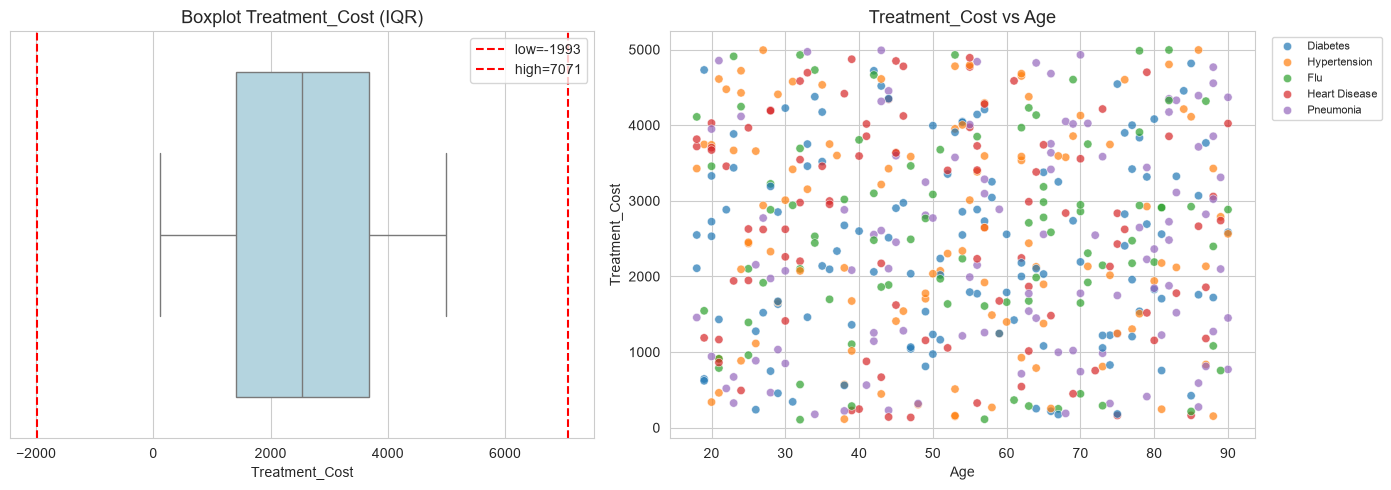

In [5]:
def iqr_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (s < lo) | (s > hi), lo, hi

mask, lo, hi = iqr_outliers(df['Treatment_Cost'])
print(f"IQR-границы Treatment_Cost: [{lo:.2f}; {hi:.2f}]")
print(f"Выбросов: {mask.sum()} ({mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['Treatment_Cost'], ax=axes[0], color='lightblue')
axes[0].axvline(lo, color='red', ls='--', label=f'low={lo:.0f}')
axes[0].axvline(hi, color='red', ls='--', label=f'high={hi:.0f}')
axes[0].set_title('Boxplot Treatment_Cost (IQR)')
axes[0].legend()

sns.scatterplot(data=df, x='Age', y='Treatment_Cost',
                hue='Diagnosis', ax=axes[1], alpha=0.7)
axes[1].set_title('Treatment_Cost vs Age')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Разведочный анализ

### 4.1. Распределения

C:\Users\саша\AppData\Local\Temp\ipykernel_18040\64452592.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Diagnosis', order=order, ax=axes[1], palette='viridis')


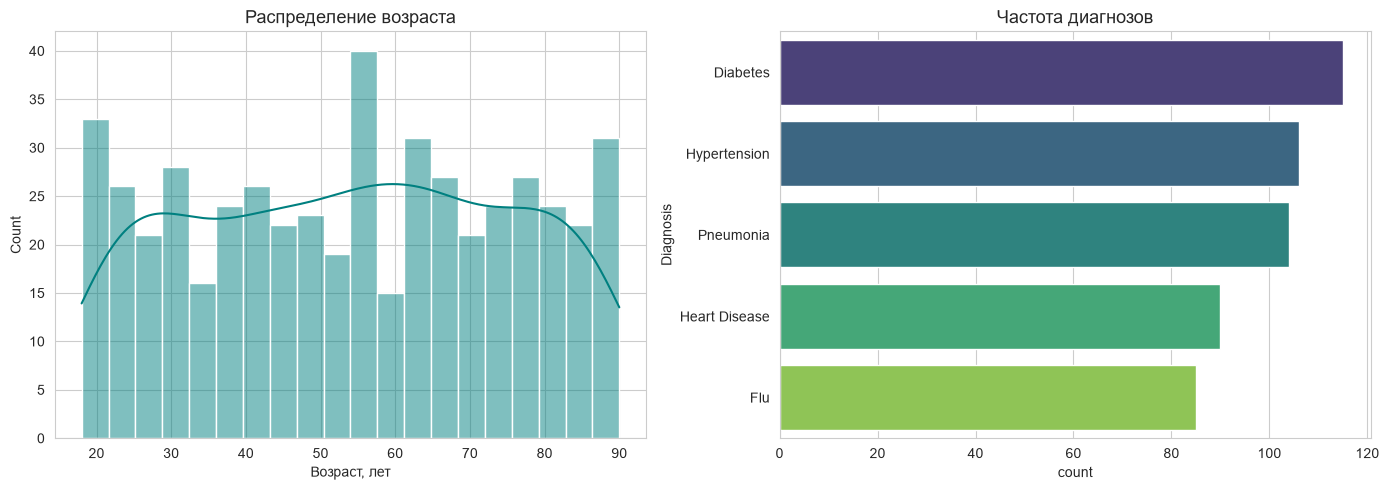

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст, лет')

order = df['Diagnosis'].value_counts().index
sns.countplot(data=df, y='Diagnosis', order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Частота диагнозов')

plt.tight_layout()
plt.show()


# Возраст распределён почти равномерно с медианой ~55 лет.
# Диагнозы сбалансированы, слегка преобладают Hypertension и Diabetes.
# Гипотеза: датасет сгенерирован равномерно, без смещений по возрасту.

### 4.2. Зависимости между признаками

C:\Users\саша\AppData\Local\Temp\ipykernel_18040\2562414028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost',


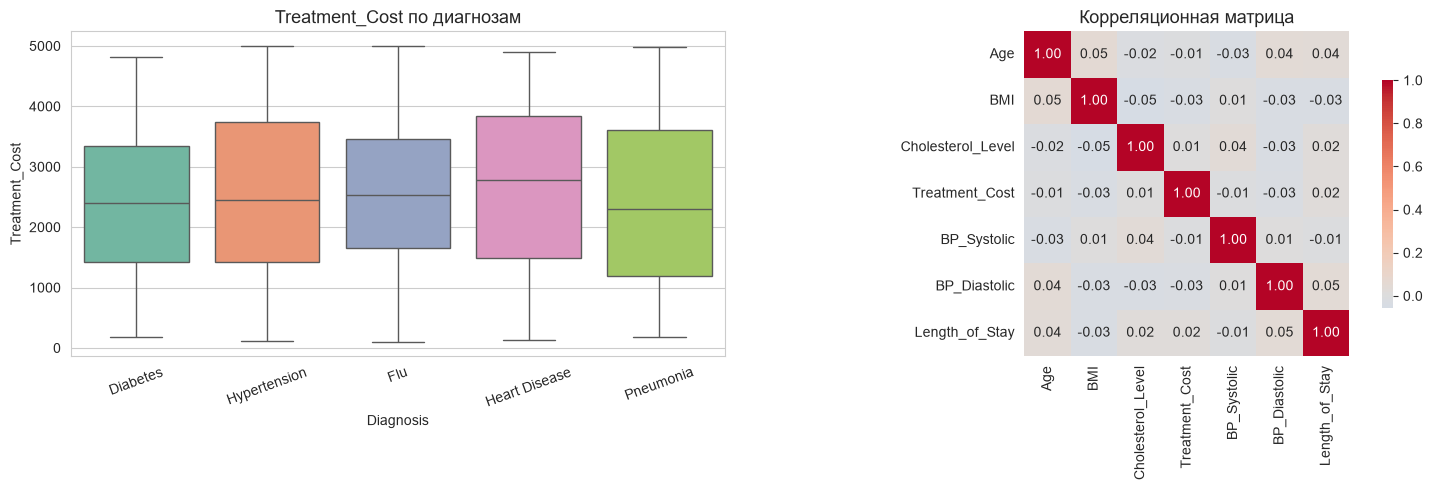

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost',
            ax=axes[0], palette='Set2')
axes[0].set_title('Treatment_Cost по диагнозам')
axes[0].tick_params(axis='x', rotation=20)

corr = df[['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
           'BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'shrink': .7})
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

# Медианная стоимость лечения слабо различается между диагнозами,
# но разброс у Heart Disease и Pneumonia шире.
# Корреляции между числовыми признаками слабые — гипотеза о независимости.